In [4]:
import os
import json
from collections import defaultdict
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

DIRPATH_ROOT = Path().resolve().parents[1]
dirpath_self = Path().resolve()
sys.path.append(str(DIRPATH_ROOT))
sys.path.append(str(dirpath_self))
print(DIRPATH_ROOT)
print(dirpath_self)

D:\WORK\Salvador\repo\A1_OUinp
D:\WORK\Salvador\repo\A1_OUinp\analysis\model_utils


In [9]:
def plot_mat(ax, da, title, sep_x=None, sep_y=None):
    vmax = float(np.nanmax(np.abs(da.values)))
    im = ax.imshow(da.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label=title)
    ax.invert_yaxis()
    pops = list(da.pop_post.values)
    ax.set_xticks(range(len(pops))); ax.set_xticklabels(list(da.pop_pre.values), rotation=45, ha='right')
    ax.set_yticks(range(len(pops))); ax.set_yticklabels(pops)
    ax.set_xlabel('Pre'); ax.set_ylabel('Post')
    ax.set_title(title)
    if sep_x is not None:
        ax.axvline(x=sep_x, color='k', lw=2)
    if sep_y is not None:
        ax.axhline(y=sep_y, color='k', lw=2)

In [5]:
fpath_conn = DIRPATH_ROOT / 'conn' / 'conn.nc'
C = xr.load_dataset(fpath_conn)
C

<xarray.Dataset>
Dimensions:   (pop_post: 43, pop_pre: 43)
Coordinates:
  * pop_post  (pop_post) object 'IT2' 'IT3' 'ITP4' 'ITS4' ... 'IREM' 'TI' 'TIM'
  * pop_pre   (pop_pre) object 'IT2' 'IT3' 'ITP4' 'ITS4' ... 'IREM' 'TI' 'TIM'
Data variables:
    pmat      (pop_post, pop_pre) float64 0.1971 0.1971 0.01971 ... nan nan 0.53
    wmat      (pop_post, pop_pre) float64 0.36 0.36 0.34 0.34 ... nan nan 0.5
    N         (pop_pre) int32 338 4461 837 837 359 359 ... 155 38 155 155 51 51
    r         (pop_pre) float64 2.0 2.0 2.0 2.0 5.0 ... 8.0 15.0 10.0 15.0 10.0

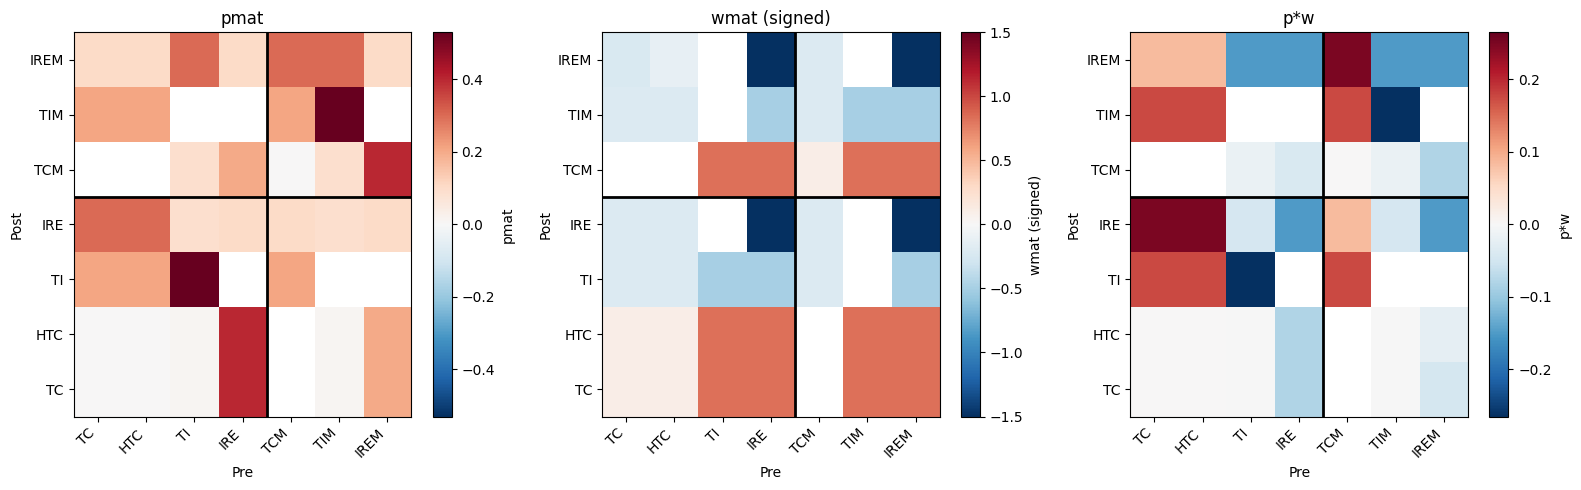

In [14]:
THAL_POPS = ['TC', 'HTC', 'TI', 'IRE', 'TCM', 'TIM', 'IREM']
CORE_POPS = ['TC', 'HTC', 'TI', 'IRE']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']

pmat = C['pmat'].sel(pop_post=THAL_POPS, pop_pre=THAL_POPS)
wmat = C['wmat'].sel(pop_post=THAL_POPS, pop_pre=THAL_POPS)
N    = C['N'].sel(pop_pre=THAL_POPS)
r    = C['r'].sel(pop_pre=THAL_POPS)

# Sign inhibitory presynaptic populations
pre_inh = xr.DataArray([p in THAL_I_POPS for p in THAL_POPS], dims='pop_pre', coords={'pop_pre': THAL_POPS})
wmat_s  = xr.where(pre_inh, -wmat, wmat)

pw   = pmat * wmat_s
pw_N = pw * N
pw_Nr = pw * N * r

sep = len(CORE_POPS) - 0.5
#fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
data_vis = zip(
    axes.ravel(),
    #[pmat, wmat_s, pw, pw_N, pw_Nr],
    #['pmat', 'wmat (signed)', 'p*w', 'p*w*N', 'p*w*N*r']
    [pmat, wmat_s, pw],
    ['pmat', 'wmat (signed)', 'p*w']
)
for ax, da, title in data_vis:
    plot_mat(ax, da, title, sep_x=sep, sep_y=sep)
#axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()
